In [1]:
import pickle
import pandas as pd
import seaborn as sns


# Load the data
norm = 'networknorm'
num_nodes_values = range(1000, 5001, 1000)
density_values = [0.001, 0.005, 0.01]

dfs = []
for num_nodes in num_nodes_values:
    for density in density_values:
        with open(f'./synthetic_characterization_output/scalar_{norm}_{density}_{num_nodes}.pkl', 'rb') as f:
            scalar_raw = pickle.load(f)

        df = pd.DataFrame.from_dict(scalar_raw).T
        # df = df.dropna(axis=1)
        dfs.append(df)

merged_df = pd.concat(dfs)
merged_df.dropna(axis=1, inplace=True, how='any')

In [37]:
merged_df.shape

(7500, 33)

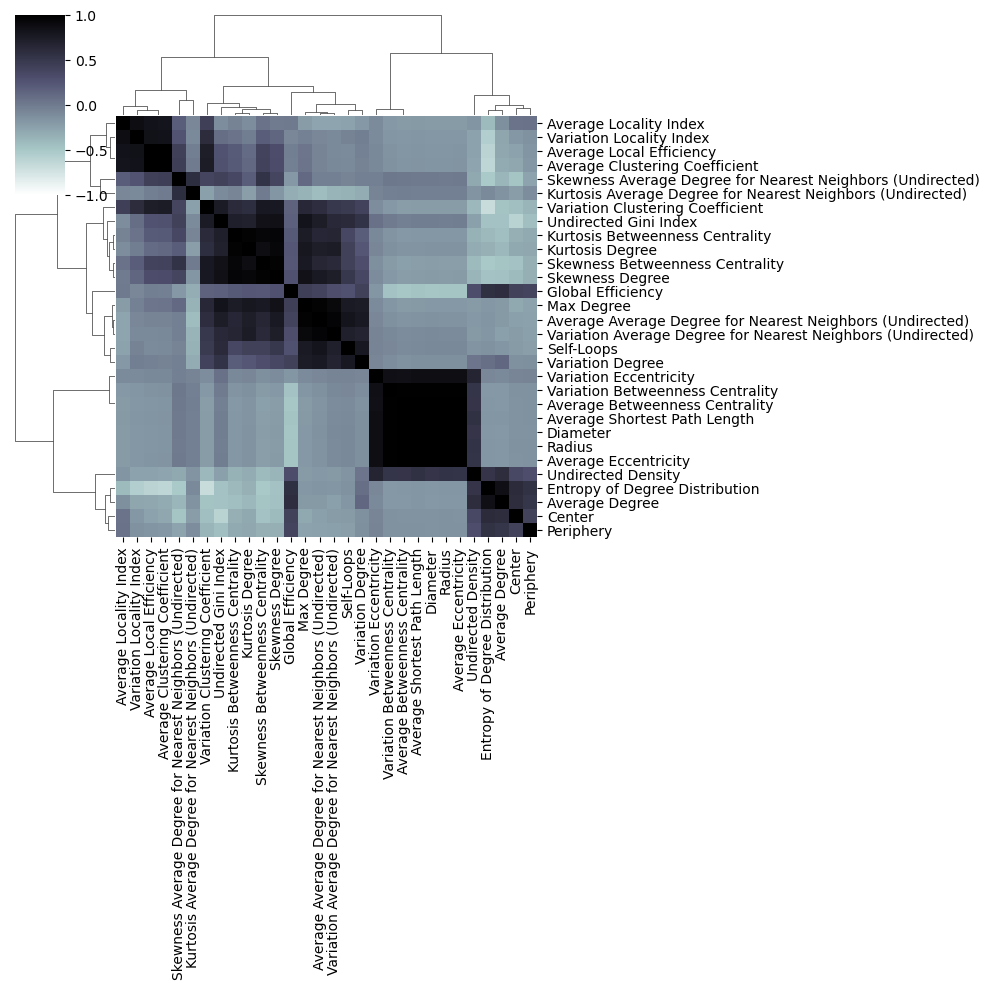

In [3]:
merged_df_corr = merged_df.corr()
merged_df_corr.dropna(axis=1, how='all', inplace=True)
merged_df_corr.dropna(axis=0, how='all', inplace=True)
ax = sns.clustermap(merged_df_corr,xticklabels=True, yticklabels=True, cmap='bone_r', vmin=-1, vmax=1, method='ward', metric='euclidean')

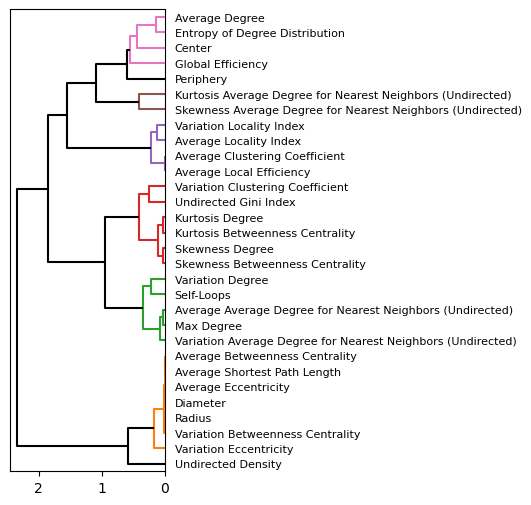

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# dist_mtrx = np.sqrt(2*(1 - abs(merged_df_corr.to_numpy())))
dist_mtrx = 1 - abs(merged_df_corr.to_numpy())
condensed_square_matrix = squareform(dist_mtrx)
linkage_mtrx = linkage(condensed_square_matrix, method='ward', metric='euclidean')
index = list(merged_df_corr.index)
relative_max_intracluster_d = linkage_mtrx[:, 2].max()*0.25 # The distance between clusters Z[i, 0] and Z[i, 1] is given by Z[i, 2].
cluster_vector = fcluster(linkage_mtrx, criterion="distance", t=relative_max_intracluster_d)
clusters = {i: [] for i in cluster_vector}
[clusters[cluster_vector[i]].append(index[i]) for i in range(len(cluster_vector))];
clusters_with_redundancy = [v for k, v in clusters.items() if len(v) > 1]
clusters_without_redundancy = [v for k, v in clusters.items() if len(v) == 1]
props_without_redundancy = [item for sublist in clusters_without_redundancy for item in sublist]

# plot
plt.figure(figsize=(2, 6))
dendrogram(linkage_mtrx, orientation='left', labels=index, leaf_rotation=0, leaf_font_size=8, color_threshold=relative_max_intracluster_d, above_threshold_color='k');

In [5]:
props_without_redundancy

['Periphery', 'Undirected Density']

In [6]:
# Select a threshold for correlation
threshold = 0.5
correlation_matrix = merged_df_corr.copy()
df = merged_df.copy()

def select_representative_feature(cluster, threshold, correlation_matrix):
    avg_corr_with_others = {}
    for feature1 in cluster:
        # Calculate the average correlation of feature1 with other features in the cluster
        avg_corr = sum([abs(correlation_matrix.loc[feature1, feature2]) for feature2 in cluster if feature1 != feature2]) / (len(cluster) - 1)
        avg_corr_with_others[feature1] = avg_corr
    
    # Select the feature with the highest average correlation
    representative_feature = max(avg_corr_with_others, key=avg_corr_with_others.get) if max(avg_corr_with_others.values()) >= threshold else None
    return representative_feature

representative_features = props_without_redundancy.copy()
for cluster in clusters_with_redundancy:
    representative_feature = select_representative_feature(cluster, threshold, correlation_matrix)
    representative_features.append(representative_feature)


representative_features

['Periphery',
 'Undirected Density',
 'Average Local Efficiency',
 'Average Eccentricity',
 'Average Degree',
 'Average Average Degree for Nearest Neighbors (Undirected)',
 'Skewness Degree',
 'Skewness Average Degree for Nearest Neighbors (Undirected)']

In [13]:
sub_corr = merged_df[['Periphery',
 'Undirected Density',
 'Average Local Efficiency',
 'Average Eccentricity',
 'Average Degree',
 'Average Average Degree for Nearest Neighbors (Undirected)',
 'Skewness Degree',
 'Skewness Average Degree for Nearest Neighbors (Undirected)']].T.corr()

# sns.clustermap(sub_corr,xticklabels=True, yticklabels=True, cmap='bone_r', vmin=-1, vmax=1, method='ward', metric='euclidean')

In [36]:
from netective.utils import get_clusters

clusters = get_clusters(sub_corr, clust_num=5, map_ids=True)

In [34]:
len(clusters[5])

4903

In [23]:
sum([len(v) for k, v in clusters.items()])

7500

In [17]:
sub_corr

,ba_graph_0.001_1000_0,er_graph_0.001_1000_0,ws_graph_0.001_1000_0,dgm_graph_0.001_1000_0,sf_graph_0.001_1000_0,ba_graph_0.001_1000_1,er_graph_0.001_1000_1,ws_graph_0.001_1000_1,dgm_graph_0.001_1000_1,sf_graph_0.001_1000_1,...,ba_graph_0.01_5000_98,er_graph_0.01_5000_98,ws_graph_0.01_5000_98,dgm_graph_0.01_5000_98,sf_graph_0.01_5000_98,ba_graph_0.01_5000_99,er_graph_0.01_5000_99,ws_graph_0.01_5000_99,dgm_graph_0.01_5000_99,sf_graph_0.01_5000_99
ba_graph_0.001_1000_0,1.000000,0.915966,0.611268,0.981446,0.968813,0.998423,0.920092,0.601810,0.981446,0.963467,...,0.984372,-0.086874,0.004390,0.980741,0.968179,0.965708,0.964707,-0.010325,0.980741,0.966863
er_graph_0.001_1000_0,0.915966,1.000000,0.786377,0.846463,0.820796,0.899584,0.997564,0.781183,0.846463,0.810469,...,0.853668,-0.155605,-0.064262,0.844724,0.820287,0.825438,0.938924,-0.093681,0.844724,0.817707
ws_graph_0.001_1000_0,0.611268,0.786377,1.000000,0.460381,0.397406,0.566020,0.743151,0.999916,0.460381,0.378379,...,0.464907,-0.199320,-0.088095,0.450022,0.395018,0.434865,0.787422,-0.144982,0.450022,0.390221
dgm_graph_0.001_1000_0,0.981446,0.846463,0.460381,1.000000,0.994899,0.989732,0.860737,0.449828,1.000000,0.993186,...,0.998626,-0.079812,0.008454,0.999500,0.994525,0.978968,0.906191,0.004754,0.999500,0.994112
sf_graph_0.001_1000_0,0.968813,0.820796,0.397406,0.994899,1.000000,0.981167,0.839814,0.386566,0.994899,0.999785,...,0.996980,-0.063240,0.007538,0.997353,0.999973,0.979772,0.873702,0.008439,0.997353,0.999947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ba_graph_0.01_5000_99,0.965708,0.825438,0.434865,0.978968,0.979772,0.974719,0.838253,0.424087,0.978968,0.978218,...,0.980238,0.117616,0.194867,0.980403,0.979787,1.000000,0.874779,0.191078,0.980403,0.979495
er_graph_0.01_5000_99,0.964707,0.938924,0.787422,0.906191,0.873702,0.949093,0.926936,0.779872,0.906191,0.863611,...,0.908008,-0.176081,-0.064602,0.901176,0.872133,0.874779,1.000000,-0.093807,0.901176,0.869591
ws_graph_0.01_5000_99,-0.010325,-0.093681,-0.144982,0.004754,0.008439,-0.003402,-0.100338,-0.147769,0.004754,0.010173,...,-0.004114,0.984664,0.998014,0.003103,0.009411,0.191078,-0.093807,1.000000,0.003103,0.010210
dgm_graph_0.01_5000_99,0.980741,0.844724,0.450022,0.999500,0.997353,0.989788,0.860051,0.439426,0.999500,0.995906,...,0.999590,-0.076741,0.005953,1.000000,0.997099,0.980403,0.901176,0.003103,1.000000,0.996756


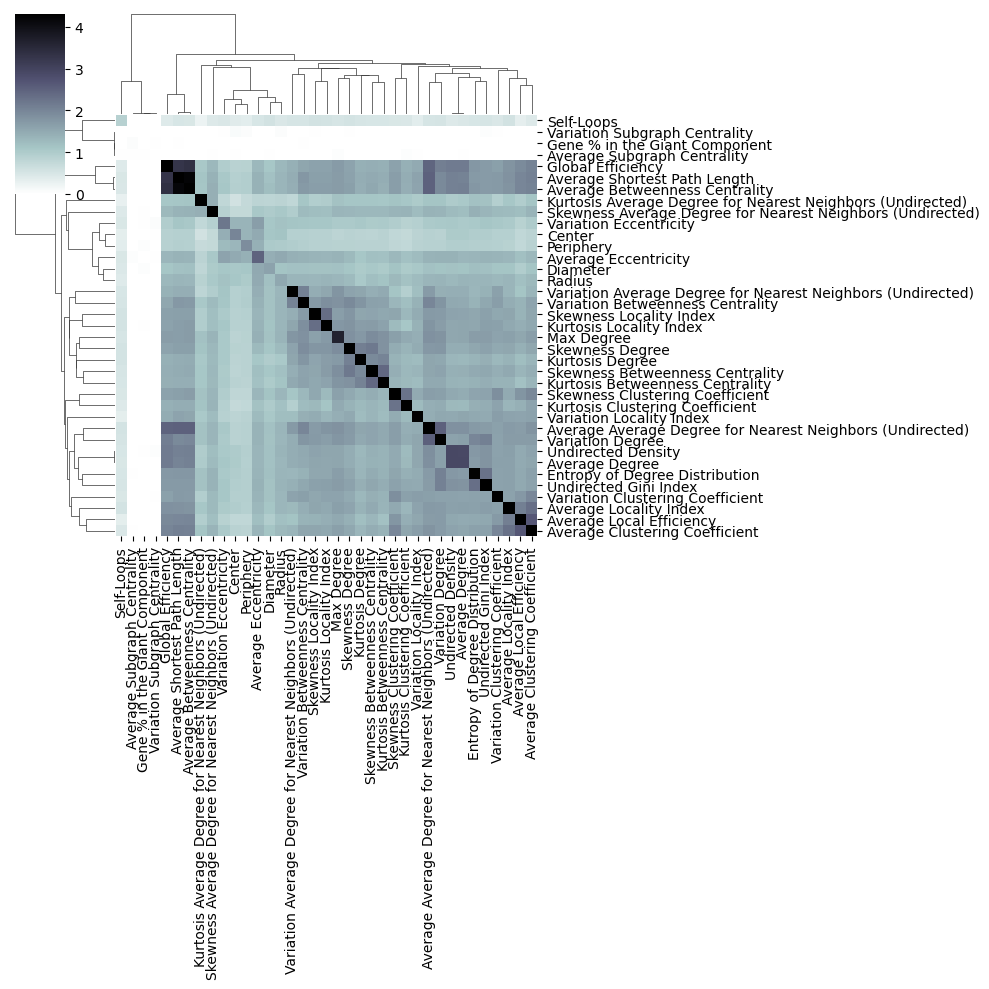

In [232]:
from sklearn.feature_selection import mutual_info_regression
import pickle
import pandas as pd

norm = 'networknorm'
num_nodes_values = range(1000, 5001, 1000)
density_values = [0.001, 0.005, 0.01]

dfs = []
for num_nodes in num_nodes_values:
    for density in density_values:
        with open(f'scalar_{norm}_{density}_{num_nodes}.pkl', 'rb') as f:
            scalar_raw = pickle.load(f)

        df = pd.DataFrame.from_dict(scalar_raw).T
        df = df.dropna(axis=1)
        dfs.append(df)

merged_df = pd.concat(dfs)

merged_df_corr = pd.DataFrame(index=df.columns, columns=df.columns)
for i in df.columns:
    for j in df.columns:
        merged_df_corr.loc[i,j] = mutual_info_regression(df[[i]], df[j])[0]


sns.clustermap(merged_df_corr.astype(float),xticklabels=True, yticklabels=True, cmap='bone_r')

# Edges

In [149]:
with open('edges_0.01_5000.pkl', 'rb') as f:
    edges = pickle.load(f)

type_density_nodes_edges = []
for name, num_edges in edges.items():
    net_type, _, density, num_nodes, _ = name.split('_')
    type_density_nodes_edges.append([net_type, density, num_nodes, num_edges])

In [158]:
df.edges.max()

126143

edges    Axes(0.125,0.11;0.775x0.77)
dtype: object

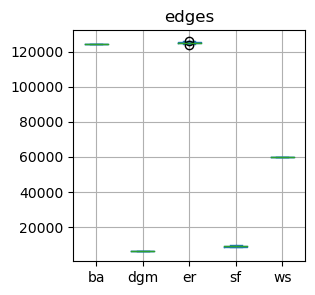

In [168]:
df = pd.DataFrame.from_records(type_density_nodes_edges, columns=['type', 'density', 'nodes', 'edges'], coerce_float=True)
df.plot.box(by='type', column=['edges'], grid=True, figsize=(3,3))

In [175]:
(5000**2)/2*0.01

125000.0

In [188]:
df

,type,density,nodes,edges
0,ba,0.01,5000,124375
1,er,0.01,5000,125192
2,ws,0.01,5000,60000
3,dgm,0.01,5000,6561
4,sf,0.01,5000,8541
...,...,...,...,...
495,ba,0.01,5000,124375
496,er,0.01,5000,125406
497,ws,0.01,5000,60000
498,dgm,0.01,5000,6561


nodes    Axes(0.125,0.11;0.775x0.77)
dtype: object

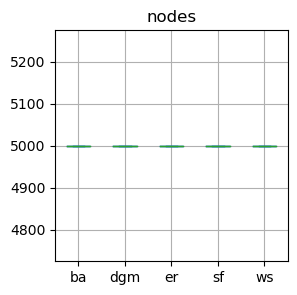

In [176]:
df.nodes = df.nodes.astype(int)
df.plot.box(by='type', column=['nodes'], grid=True, figsize=(3,3))

density    Axes(0.125,0.11;0.775x0.77)
dtype: object

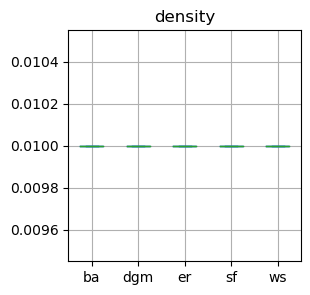

In [185]:
df.density = df.density.astype(float)
df.plot.box(by='type', column=['density'], grid=True, figsize=(3,3))